# Phase 3 — Transformer léger sur FD002 (régime-aware)

Objectif : même Transformer que sur FD001, entraîné cette fois sur le pipeline régime-aware de
FD002 (`11_fd002_ablation_regime.ipynb`, variante "par régime" : sélection et normalisation par
régime, 14 capteurs), pour comparer à la meilleure configuration LSTM sur FD002.

Critère « fait » (plan d'exécution, Phase 3) : scores sur les deux volets (FD001 fait dans
`13_transformer_fd001.ipynb`, FD002 ici).

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd
import torch

from src.metrics import asymmetric_score, rmse
from src.preprocessing import (
    add_piecewise_rul,
    assign_regimes,
    compute_norm_stats_by_regime,
    fit_regime_clusters,
    make_windows,
    normalize_by_regime,
    select_features_by_regime,
    split_by_unit,
)
from src.torch_model import TransformerRULRegressor, set_seed, train_model

SEED = 42
WINDOW_SIZE = 30
RUL_CAP = 125

DATA_DIR = "../DATA/CMaps"
INDEX_NAMES = ["unit_number", "time_cycles"]
SETTING_NAMES = ["setting_1", "setting_2", "setting_3"]
SENSOR_NAMES = [f"sensor_{i}" for i in range(1, 22)]
COL_NAMES = INDEX_NAMES + SETTING_NAMES + SENSOR_NAMES

raw = pd.read_csv(f"{DATA_DIR}/train_FD002.txt", sep=r"\s+", header=None)
raw = raw.iloc[:, : len(COL_NAMES)]
raw.columns = COL_NAMES

train_raw, val_raw = split_by_unit(raw, val_fraction=0.2, seed=SEED)

regime_model = fit_regime_clusters(train_raw, SETTING_NAMES, n_regimes=6, seed=SEED)
train_regimes = assign_regimes(train_raw, SETTING_NAMES, regime_model)
val_regimes = assign_regimes(val_raw, SETTING_NAMES, regime_model)

selected_sensors = select_features_by_regime(train_raw, SENSOR_NAMES, train_regimes, std_threshold=1e-2)
regime_stats = compute_norm_stats_by_regime(train_raw, selected_sensors, train_regimes)
train_norm = normalize_by_regime(train_raw, selected_sensors, train_regimes, regime_stats)
val_norm = normalize_by_regime(val_raw, selected_sensors, val_regimes, regime_stats)

train_rul = add_piecewise_rul(train_norm, cap=RUL_CAP)
val_rul = add_piecewise_rul(val_norm, cap=RUL_CAP)

X_train, y_train, _ = make_windows(train_rul, selected_sensors, window_size=WINDOW_SIZE, target_col="RUL")
X_val, y_val, _ = make_windows(val_rul, selected_sensors, window_size=WINDOW_SIZE, target_col="RUL")

X_train.shape, X_val.shape

((37051, 30, 14), (9168, 30, 14))

In [2]:
set_seed(SEED)  # avant la construction du modèle : l'initialisation des poids en dépend
model = TransformerRULRegressor(n_features=len(selected_sensors), window_size=WINDOW_SIZE, d_model=64, nhead=4, num_layers=1)

model, history = train_model(model, X_train, y_train, X_val, y_val, epochs=50, lr=1e-3, batch_size=64, seed=SEED)
history_df = pd.DataFrame(history)
history_df.tail()

,epoch,train_loss,val_rmse
45,45,122.362932,19.020121
46,46,121.839057,19.067772
47,47,120.406967,19.315486
48,48,117.299225,19.440963
49,49,116.434916,19.471938


In [3]:
model.eval()
with torch.no_grad():
    device = next(model.parameters()).device
    y_pred = model(torch.tensor(X_val, dtype=torch.float32, device=device)).cpu().numpy()

# Score LSTM régime-aware obtenu dans 11_fd002_ablation_regime.ipynb (même split, mêmes
# capteurs, même normalisation) : recopié ici pour comparaison directe, pas recalculé.
comparison = pd.DataFrame([
    {"modèle": "LSTM (régime-aware)", "RMSE": 15.074154, "score_asymétrique": 42105.297588},
    {"modèle": "Transformer (régime-aware)", "RMSE": rmse(y_val, y_pred), "score_asymétrique": asymmetric_score(y_val, y_pred)},
])
comparison

,modèle,RMSE,score_asymétrique
0,LSTM (régime-aware),15.074154,42105.297588
1,Transformer (régime-aware),15.633626,50027.646116


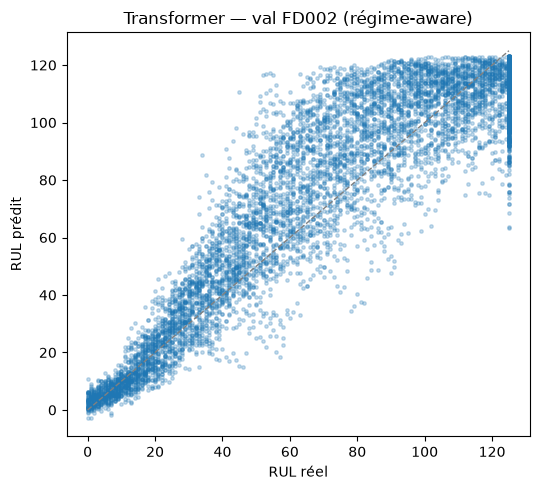

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(y_val, y_pred, s=6, alpha=0.25)
ax.plot([0, RUL_CAP], [0, RUL_CAP], color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("RUL réel")
ax.set_ylabel("RUL prédit")
ax.set_title("Transformer — val FD002 (régime-aware)")
fig.tight_layout()

**Ce que montre cette figure** : même lecture que sur FD001 — proximité à la diagonale = bonne
prédiction. Le nuage est plus dense qu'en Phase 1 (9168 fenêtres de val contre 3272), FD002
ayant beaucoup plus de moteurs. À comparer au tableau ci-dessus : si le Transformer reproduit
sur FD002 l'écart (ou l'absence d'écart) observé avec le LSTM sur FD001, ça confirmerait que la
comparaison des deux architectures ne dépend pas du jeu de données choisi.

In [5]:
# Sauvegarde des poids, pour la démo interactive de app.py, sans ré-entraînement.
import os

os.makedirs("../models", exist_ok=True)
torch.save(model.state_dict(), "../models/transformer_fd002_seed42.pt")